# Borges Text Analysis

Notebook version of the analysis in `source.py`.

This notebook loads the CSV, normalizes the metadata, cleans the text, explores the corpus, and runs a simple baseline classifier.

## 1. Check the Current File Type

The original analysis lived in a Python script. This notebook keeps the same workflow in an interactive `.ipynb` format.

## 2. Create a New Jupyter Notebook File

This notebook is saved as `source.ipynb` in the project workspace so it can be opened and run directly in VS Code.

In [1]:
import ast
import math
import re
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


df = pd.read_csv('borges_full_texts.csv', encoding='utf-8')
metadata = df['text_metadata'].apply(ast.literal_eval)
df['titulo'] = metadata.apply(lambda item: item.get('title', ''))
df['tema'] = metadata.apply(lambda item: str(item.get('metadata', '')).strip('[]'))
df['texto'] = df['text']

df[['titulo', 'tema', 'texto']].head()

,titulo,tema,texto
0,Abel y Caín,Minicuento - Texto completo.,Abel y Caín se encontraron después de la muert...
1,Adrogué,Minicuento - Texto completo.,"Era muy lindo, un pueblo laberíntico. A veces,..."
2,Alguien soñará,Minicuento - Texto completo.,¿Qué soñará el indescifrable futuro? Soñará qu...
3,Andrés Armoa,Minicuento - Texto completo.,Los años le han dejado unas palabras en guaran...
4,Argumentum ornithologicum,Minicuento - Texto completo.,Cierro los ojos y veo una bandada de pájaros. ...


## 3. Add Code Cells to the Notebook

The following cells clean the text, build a basic word-frequency view, and run a simple classifier.

In [2]:
stop_words = {
    'a', 'acá', 'ahí', 'al', 'algo', 'algunas', 'algunos', 'ante', 'antes', 'aquel', 'aquella', 'aquello',
    'aquí', 'así', 'atras', 'bajo', 'bien', 'cada', 'casi', 'como', 'con', 'contra', 'cual', 'cuales',
    'cualquier', 'cuando', 'de', 'del', 'desde', 'donde', 'dos', 'el', 'ella', 'ellas', 'ellos', 'en',
    'entre', 'era', 'erais', 'eran', 'eres', 'es', 'esa', 'esas', 'ese', 'eso', 'esos', 'esta', 'estaba',
    'estaban', 'estado', 'estais', 'estamos', 'estan', 'estar', 'estas', 'este', 'esto', 'estos', 'ha',
    'hace', 'hacia', 'han', 'hasta', 'la', 'las', 'le', 'les', 'lo', 'los', 'mas', 'me', 'mi', 'mis',
    'mucho', 'muy', 'nada', 'ni', 'no', 'nos', 'nosotros', 'o', 'os', 'otra', 'otro', 'para', 'pero', 'poco',
    'por', 'porque', 'que', 'quien', 'quienes', 'se', 'sea', 'ser', 'si', 'sin', 'sobre', 'su', 'sus', 'tambien',
    'te', 'tiene', 'tienen', 'todo', 'todos', 'tu', 'tus', 'un', 'una', 'uno', 'unos', 'y', 'ya'
}


def clean_text(text):
    tokens = re.findall(r'\b\w+\b', str(text).lower(), flags=re.UNICODE)
    return ' '.join([word for word in tokens if word.isalpha() and word not in stop_words])


df['texto_limpio'] = df['texto'].apply(clean_text)
df['word_count'] = df['texto'].apply(lambda value: len(str(value).split()))

print('--- Estadísticas Básicas ---')
print(df[['titulo', 'word_count']].head())
df[['titulo', 'word_count']].describe()

--- Estadísticas Básicas ---
                      titulo  word_count
0                Abel y Caín         153
1                    Adrogué          39
2             Alguien soñará         151
3               Andrés Armoa         260
4  Argumentum ornithologicum         115


,word_count
count,62.000000
mean,1404.225806
std,1337.345112
min,18.000000
25%,194.000000
50%,1173.500000
75%,2114.250000
max,5675.000000


## 4. Save the File with the `.ipynb` Extension

The notebook is already stored on disk as `source.ipynb` and can be executed cell by cell.

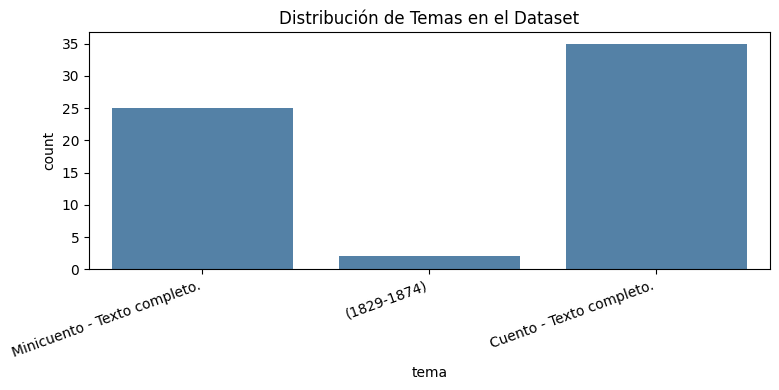

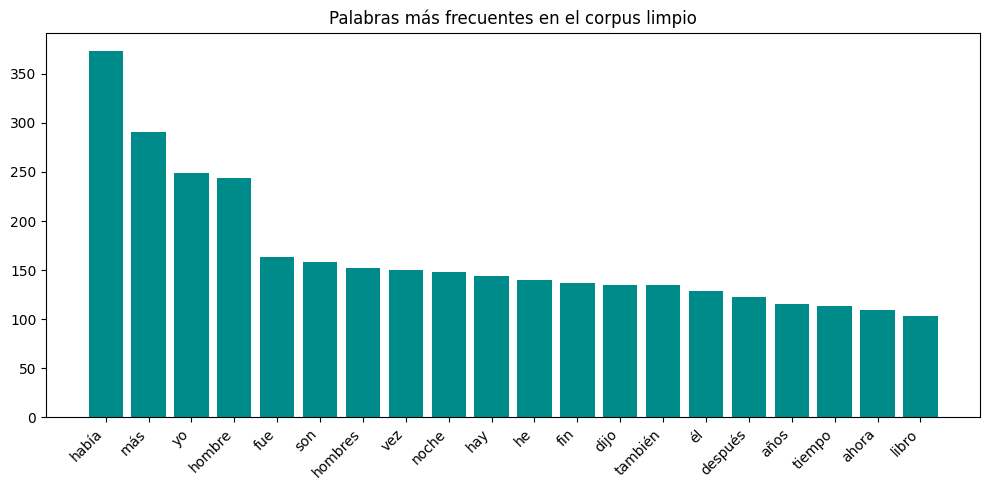

In [3]:
plt.figure(figsize=(8, 4))
sns.countplot(x='tema', data=df, color='steelblue')
plt.title('Distribución de Temas en el Dataset')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

all_words = ' '.join(df['texto_limpio'])
top_words = Counter(all_words.split()).most_common(20)

plt.figure(figsize=(10, 5))
plt.bar([word for word, _ in top_words], [count for _, count in top_words], color='darkcyan')
plt.xticks(rotation=45, ha='right')
plt.title('Palabras más frecuentes en el corpus limpio')
plt.tight_layout()
plt.show()

## 5. Verify Notebook JSON and Kernel Metadata

The notebook metadata includes a Python kernel spec, and the cell list is stored in valid notebook JSON.

In [4]:
def tokenize(text):
    return [word for word in re.findall(r'\b\w+\b', str(text).lower(), flags=re.UNICODE) if word.isalpha() and word not in stop_words]


def train_naive_bayes(texts, labels):
    class_doc_counts = Counter(labels)
    class_token_counts = defaultdict(Counter)
    class_total_tokens = Counter()
    vocabulary = set()

    for text, label in zip(texts, labels):
        tokens = tokenize(text)
        class_token_counts[label].update(tokens)
        class_total_tokens[label] += len(tokens)
        vocabulary.update(tokens)

    return {
        'class_doc_counts': class_doc_counts,
        'class_token_counts': class_token_counts,
        'class_total_tokens': class_total_tokens,
        'vocabulary': vocabulary,
        'total_docs': len(labels),
    }


def predict_naive_bayes(model, text):
    tokens = tokenize(text)
    vocabulary_size = max(len(model['vocabulary']), 1)
    scores = {}

    for label, doc_count in model['class_doc_counts'].items():
        score = math.log(doc_count / model['total_docs'])
        total_tokens = model['class_total_tokens'][label]
        for token in tokens:
            token_count = model['class_token_counts'][label][token]
            score += math.log((token_count + 1) / (total_tokens + vocabulary_size))
        scores[label] = score

    return max(scores, key=scores.get)


split_index = max(int(len(df) * 0.8), 1)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]
model = train_naive_bayes(train_df['texto_limpio'], train_df['tema'])
y_pred = [predict_naive_bayes(model, text) for text in test_df['texto_limpio']]

print('\n--- Resultados Preliminares del Modelo ---')
if len(test_df) > 0:
    accuracy = sum(true == pred for true, pred in zip(test_df['tema'], y_pred)) / len(test_df)
    print(f'Accuracy: {accuracy:.2f}')
    print(pd.DataFrame({'real': test_df['tema'].to_list(), 'predicho': y_pred}).head())
else:
    print('No hay suficientes filas para crear una partición de prueba.')


--- Resultados Preliminares del Modelo ---
Accuracy: 0.38
                           real                      predicho
0  Minicuento - Texto completo.      Cuento - Texto completo.
1  Minicuento - Texto completo.  Minicuento - Texto completo.
2      Cuento - Texto completo.      Cuento - Texto completo.
3  Minicuento - Texto completo.      Cuento - Texto completo.
4  Minicuento - Texto completo.      Cuento - Texto completo.
